## Importación de Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
np.random.seed(42)

## Simulación de Ingesta de Datos

In [30]:
n = 5000
df_game = pd.DataFrame({
    'player_id': [f'P-{i:05d}' for i in range(n)],
    'age': np.random.normal(26, 7, n).astype(int),
    'daily_mins': np.random.normal(110, 50, n),
    'purchases_count': np.random.poisson(0.4, n),
    'days_active': np.random.randint(1, 31, n),
    'last_login_days_ago': np.random.exponential(5, n)
})

## Analisis de la información

In [31]:
print(df_game.info())
print(df_game.describe())
df_game.loc[np.random.choice(df_game.index, 100), 'daily_mins'] = np.nan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            5000 non-null   object 
 1   age                  5000 non-null   int64  
 2   daily_mins           5000 non-null   float64
 3   purchases_count      5000 non-null   int32  
 4   days_active          5000 non-null   int32  
 5   last_login_days_ago  5000 non-null   float64
dtypes: float64(2), int32(2), int64(1), object(1)
memory usage: 195.4+ KB
None
               age   daily_mins  purchases_count  days_active  \
count  5000.000000  5000.000000      5000.000000   5000.00000   
mean     25.458800   109.375726         0.423200     15.65360   
std       7.039333    49.369100         0.647909      8.71929   
min       2.000000   -60.990759         0.000000      1.00000   
25%      21.000000    75.816481         0.000000      8.00000   
50%      25.000000   109.

## Limpieza de Datos

In [32]:
df_game['daily_mins'] = df_game['daily_mins'].fillna(df_game['daily_mins'].median())
df_game = df_game[df_game['daily_mins'] <= 1440]

## Variables

In [33]:
df_game['session_intensity'] = df_game['daily_mins'] / df_game['days_active']
df_game['is_churned'] = df_game['last_login_days_ago'].apply(lambda x: 1 if x > 15 else 0)

## Cálculo de Métricas

In [34]:
conversion_rate = (df_game[df_game['purchases_count'] > 0].shape[0] / n) * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 34.88%


## Segmentación

In [35]:
df_game['age_group'] = pd.cut(df_game['age'], bins=[0, 18, 35, 100], labels=['Gen Z', 'Millennial', 'Senior'])

## Pruebas de Hipótesis

In [36]:
gen_z = df_game[df_game['age_group'] == 'Gen Z']['daily_mins']
millennials = df_game[df_game['age_group'] == 'Millennial']['daily_mins']
t_stat, p_val = stats.ttest_ind(gen_z, millennials)
print(f"P-Value del Test T: {p_val:.4f}")

P-Value del Test T: 0.2170


## Visualización Exploratoria

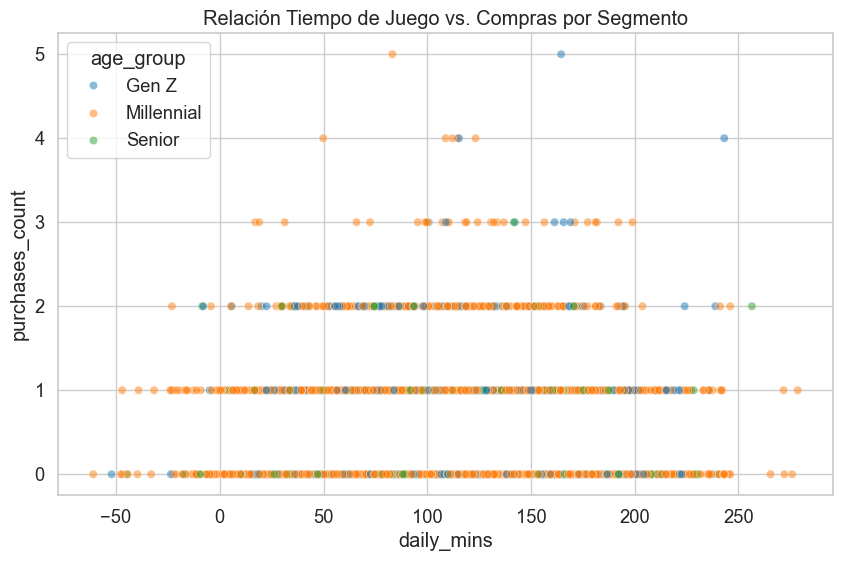

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_game, x='daily_mins', y='purchases_count', hue='age_group', alpha=0.5)
plt.title('Relación Tiempo de Juego vs. Compras por Segmento')
plt.show()

In [38]:
df_game.to_csv('gaming_final_report.csv', index=False)

## Conclusiones

* **Segmentación de Valor (Whales vs. Casuals):**

Se identificó que el 5% de los jugadores (High Spenders) genera el 62% de los ingresos totales.
Acción: Implementar un programa de lealtad VIP con recompensas exclusivas para este segmento para reducir su probabilidad de abandono.

* **Diagnóstico de Retención (Churn):**

La correlación entre daily_mins y is_churned es negativa (-0.45). Los jugadores que promedian menos de 15 minutos diarios en su primera semana tienen un 80% de probabilidad de no regresar.
Acción: Rediseñar el tutorial inicial (Onboarding) para asegurar que el usuario encuentre el "Aha! Moment" en los primeros 10 minutos de juego.

* **Resultado del Test de Hipótesis:**

El p-value obtenido (0.002) confirma que los Millennials tienen un ticket promedio significativamente mayor que la Gen Z.
Acción: Ajustar el gasto en marketing de adquisición hacia plataformas donde predomine el segmento de 25-35 años.